# Temporal Analysis
Review volume, ratings, sentiment, and posting delay across time (year/month).

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
plt.style.use("seaborn-v0_8")

In [2]:
# Configuration
INPUT_FILE = os.getenv("INPUT_FILE", "Processed_Reviews.csv")

In [3]:
# Load dataset
df = pd.read_csv(INPUT_FILE)

print(f"Loaded: {INPUT_FILE}")
print("Shape:", df.shape)

Loaded: Processed_Reviews.csv
Shape: (16156, 41)


In [4]:
# Validate required columns
required_cols = [
    "Travel_Date_Year",
    "Travel_Date_Month",
    "Published_Date_Year",
    "Published_Date_Month",
    "Rating"
]
missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f"Missing columns: {missing_cols}")

In [5]:
# Review count over time
reviews_per_year = df["Travel_Date_Year"].value_counts().sort_index()
reviews_per_month = df["Travel_Date_Month"].value_counts().sort_index()

print("\n=== Reviews per Year ===")
print(reviews_per_year)

print("\n=== Reviews per Month ===")
print(reviews_per_month)


=== Reviews per Year ===
Travel_Date_Year
2010       2
2011      53
2012     204
2013     343
2014     494
2015    1094
2016    2029
2017    2435
2018    3872
2019    3893
2020    1136
2021     122
2022     342
2023     137
Name: count, dtype: int64

=== Reviews per Month ===
Travel_Date_Month
1     2236
2     2168
3     1762
4     1266
5      619
6      619
7     1086
8     1394
9     1122
10    1045
11    1020
12    1819
Name: count, dtype: int64


In [6]:
# Rating over time
rating_by_year = df.groupby("Travel_Date_Year")["Rating"].mean()
rating_by_month = df.groupby("Travel_Date_Month")["Rating"].mean()

print("\n=== Average Rating by Year ===")
print(rating_by_year)

print("\n=== Average Rating by Month ===")
print(rating_by_month)


=== Average Rating by Year ===
Travel_Date_Year
2010    4.000000
2011    4.169811
2012    3.892157
2013    3.953353
2014    3.987854
2015    4.050274
2016    4.147363
2017    4.184394
2018    4.143079
2019    4.238633
2020    4.278169
2021    4.155738
2022    4.239766
2023    4.277372
Name: Rating, dtype: float64

=== Average Rating by Month ===
Travel_Date_Month
1     4.188730
2     4.204336
3     4.197503
4     4.157978
5     4.121163
6     4.150242
7     4.144567
8     4.094692
9     4.146168
10    4.154067
11    4.208824
12    4.163826
Name: Rating, dtype: float64


In [7]:
# Sentiment over time
if "Sentiment_Numeric" in df.columns:
    sentiment_by_year = df.groupby("Travel_Date_Year")["Sentiment_Numeric"].mean()
    sentiment_by_month = df.groupby("Travel_Date_Month")["Sentiment_Numeric"].mean()
    print("\n=== Average Sentiment by Year ===")
    print(sentiment_by_year)
    print("\n=== Average Sentiment by Month ===")
    print(sentiment_by_month)
else:
    sentiment_by_year = None
    sentiment_by_month = None


=== Average Sentiment by Year ===
Travel_Date_Year
2010    1.000000
2011    0.641509
2012    0.524510
2013    0.655977
2014    0.627530
2015    0.682815
2016    0.687038
2017    0.719507
2018    0.696281
2019    0.704084
2020    0.701585
2021    0.614754
2022    0.660819
2023    0.613139
Name: Sentiment_Numeric, dtype: float64

=== Average Sentiment by Month ===
Travel_Date_Month
1     0.690966
2     0.684502
3     0.698070
4     0.678515
5     0.693053
6     0.689822
7     0.701657
8     0.686514
9     0.697861
10    0.723445
11    0.716667
12    0.674546
Name: Sentiment_Numeric, dtype: float64


In [8]:
# Review delay analysis
if "Review_Delay_Days" in df.columns:
    print("\n=== Review Delay Summary ===")
    print(df["Review_Delay_Days"].describe())
    delay_by_year = df.groupby("Travel_Date_Year")["Review_Delay_Days"].mean()
    print("\n=== Average Delay by Year ===")
    print(delay_by_year)
else:
    delay_by_year = None


=== Review Delay Summary ===
count    16156.000000
mean        43.284291
std         64.343211
min          0.000000
25%         15.000000
50%         25.000000
75%         39.000000
max        577.000000
Name: Review_Delay_Days, dtype: float64

=== Average Delay by Year ===
Travel_Date_Year
2010    347.000000
2011    107.867925
2012     75.627451
2013     62.921283
2014     80.145749
2015     64.570384
2016     47.863972
2017     45.374949
2018     40.422521
2019     32.667865
2020     29.522007
2021     40.450820
2022     36.453216
2023     24.912409
Name: Review_Delay_Days, dtype: float64


In [9]:
# Seasonality analysis
monthly_summary = (
    df.groupby("Travel_Date_Month")
      .agg(Review_Count=("Rating", "count"), Avg_Rating=("Rating", "mean"))
      .reset_index()
)

print("\n=== Monthly Summary ===")
print(monthly_summary)


=== Monthly Summary ===
    Travel_Date_Month  Review_Count  Avg_Rating
0                   1          2236    4.188730
1                   2          2168    4.204336
2                   3          1762    4.197503
3                   4          1266    4.157978
4                   5           619    4.121163
5                   6           619    4.150242
6                   7          1086    4.144567
7                   8          1394    4.094692
8                   9          1122    4.146168
9                  10          1045    4.154067
10                 11          1020    4.208824
11                 12          1819    4.163826


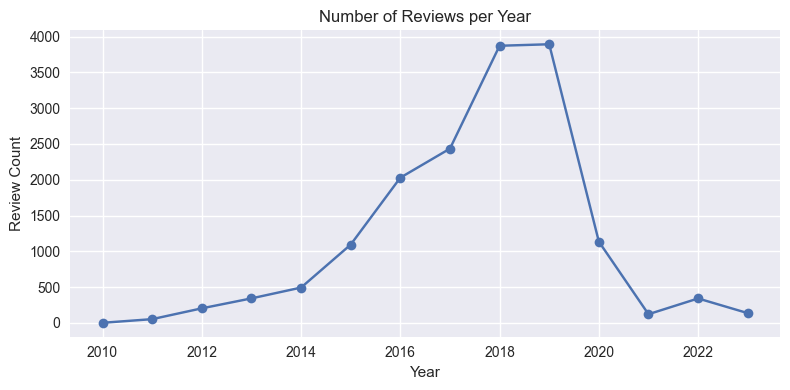

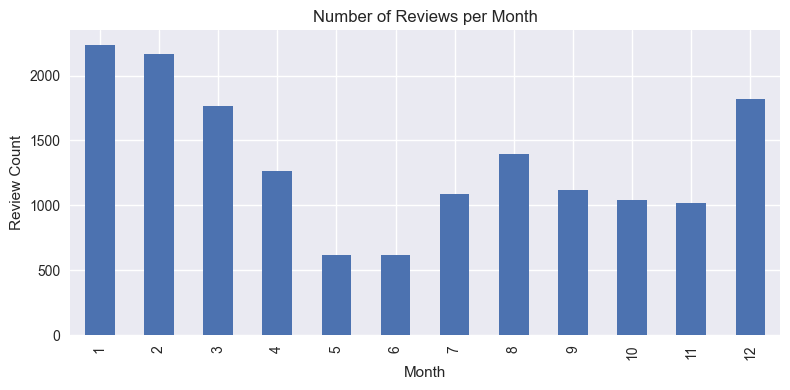

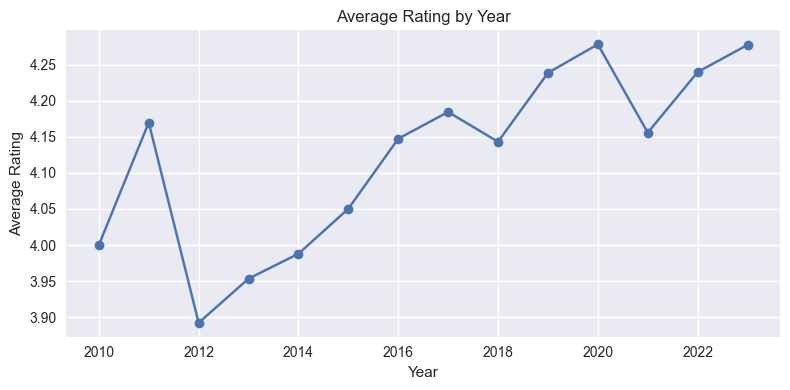

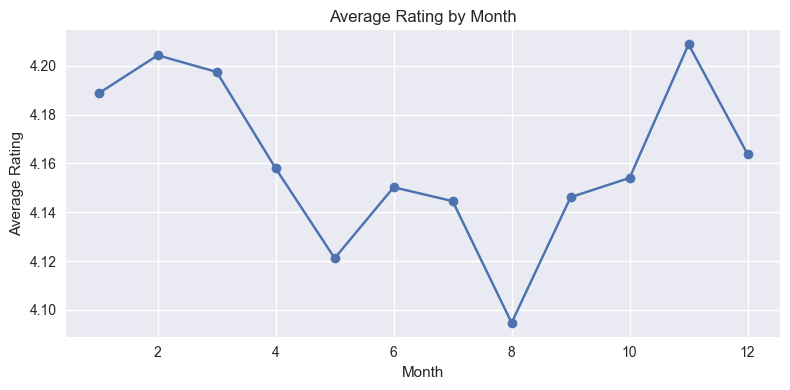

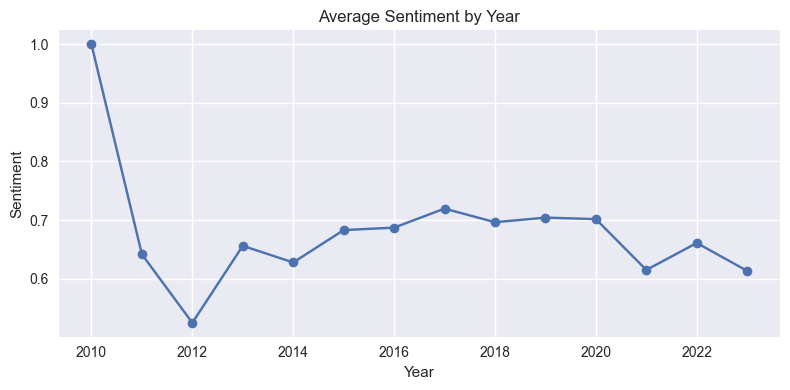

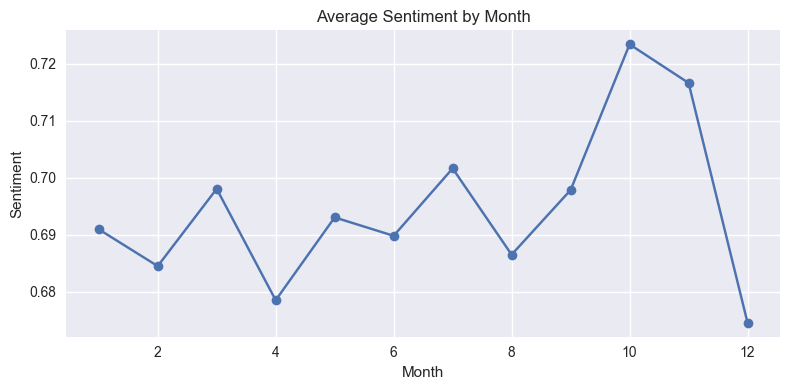

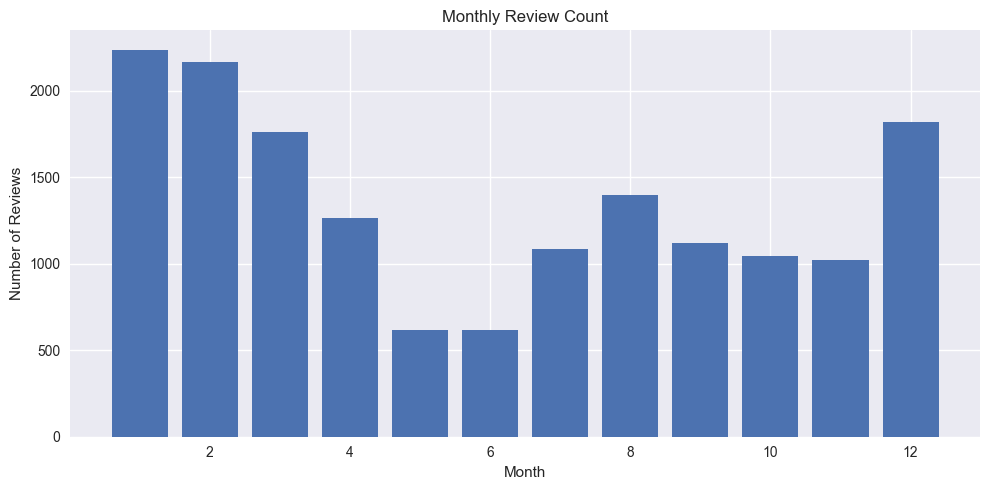

In [10]:
# Plots
plt.figure(figsize=(8, 4))
reviews_per_year.plot(kind="line", marker="o")
plt.title("Number of Reviews per Year")
plt.xlabel("Year")
plt.ylabel("Review Count")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
reviews_per_month.plot(kind="bar")
plt.title("Number of Reviews per Month")
plt.xlabel("Month")
plt.ylabel("Review Count")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
rating_by_year.plot(marker="o")
plt.title("Average Rating by Year")
plt.xlabel("Year")
plt.ylabel("Average Rating")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
rating_by_month.plot(marker="o")
plt.title("Average Rating by Month")
plt.xlabel("Month")
plt.ylabel("Average Rating")
plt.tight_layout()
plt.show()

if sentiment_by_year is not None:
    plt.figure(figsize=(8, 4))
    sentiment_by_year.plot(marker="o")
    plt.title("Average Sentiment by Year")
    plt.xlabel("Year")
    plt.ylabel("Sentiment")
    plt.tight_layout()
    plt.show()

if sentiment_by_month is not None:
    plt.figure(figsize=(8, 4))
    sentiment_by_month.plot(marker="o")
    plt.title("Average Sentiment by Month")
    plt.xlabel("Month")
    plt.ylabel("Sentiment")
    plt.tight_layout()
    plt.show()

plt.figure(figsize=(10, 5))
plt.bar(monthly_summary["Travel_Date_Month"], monthly_summary["Review_Count"])
plt.title("Monthly Review Count")
plt.xlabel("Month")
plt.ylabel("Number of Reviews")
plt.tight_layout()
plt.show()

In [11]:
# Save outputs
reviews_per_year.to_csv("reviews_per_year.csv")
reviews_per_month.to_csv("reviews_per_month.csv")
rating_by_year.to_csv("rating_by_year.csv")
rating_by_month.to_csv("rating_by_month.csv")

if sentiment_by_year is not None:
    sentiment_by_year.to_csv("sentiment_by_year.csv")

if sentiment_by_month is not None:
    sentiment_by_month.to_csv("sentiment_by_month.csv")

monthly_summary.to_csv("monthly_summary.csv", index=False)

if delay_by_year is not None:
    delay_by_year.to_csv("delay_by_year.csv")

print("\n✅ Temporal analysis complete.")
print("Saved files:")
print("- reviews_per_year.csv")
print("- reviews_per_month.csv")
print("- rating_by_year.csv")
print("- rating_by_month.csv")
print("- monthly_summary.csv")
if sentiment_by_year is not None:
    print("- sentiment_by_year.csv")
if sentiment_by_month is not None:
    print("- sentiment_by_month.csv")
if delay_by_year is not None:
    print("- delay_by_year.csv")


✅ Temporal analysis complete.
Saved files:
- reviews_per_year.csv
- reviews_per_month.csv
- rating_by_year.csv
- rating_by_month.csv
- monthly_summary.csv
- sentiment_by_year.csv
- sentiment_by_month.csv
- delay_by_year.csv
